# 2.3 — Teoremas fundamentales del asset pricing

## Motivación

En 2.1 construimos, a mano, la maquinaria de un mercado de un periodo: replicación, medida neutral al riesgo, precio como esperanza descontada. En 2.2 la aplicamos recursivamente a un árbol multi-periodo. En ambos casos la existencia de una medida martingala equivalente y su relación con el no-arbitraje y la completitud aparecieron como hechos verificados caso por caso — nunca demostrados en general. Este notebook cierra ese hueco: enunciamos y demostramos (en el caso finito) los dos **Teoremas Fundamentales del Asset Pricing (FTAP)**, que son la razón estructural por la que todo lo hecho en 2.1-2.2 funciona.

El **primer FTAP** dice que un mercado está libre de arbitraje si y solo si existe al menos una medida martingala equivalente $\mathbb{Q}$ — la existencia de $\mathbb{Q}$ no es una casualidad del binomial, es *equivalente* a la ausencia de arbitraje. El **segundo FTAP** dice que el mercado es completo (todo derivado es replicable) si y solo si esa medida es **única**. Estos dos teoremas explican exactamente lo que vimos empíricamente: el binomial de 2.1/2.2 tiene una única $\mathbb{Q}$ porque es completo (dos activos, dos estados por nodo); el trinomial de 2.1 tiene una familia de medidas y un intervalo de precios sin arbitraje precisamente porque es incompleto (dos activos, tres estados).

En el caso finito (espacio de estados discreto y finito, horizonte finito) el primer FTAP tiene una demostración corta y constructiva vía el **teorema de separación de hiperplanos** — la misma herramienta que sostiene la dualidad de programación lineal, lo cual conecta directamente con la detección algorítmica de arbitraje que hacemos en la Demo 3. Cubrimos: (i) definiciones formales de mercado finito, estrategia autofinanciada y arbitraje; (ii) 1er FTAP con esbozo de demostración; (iii) 2do FTAP y su relación con la completitud; (iv) tres demos numéricas — medida única en el binomial de 2 pasos, familia de medidas en el trinomial, y detección de arbitraje vía programación lineal (`linprog`) en un mercado de 3 activos.

## 1. Mercado finito: definiciones formales

### 1.1 El modelo

Fijamos un horizonte finito $T \in \mathbb{N}$ y un espacio muestral **finito** $\Omega = \{\omega_1, \dots, \omega_N\}$ con $\mathbb{P}(\omega_i) > 0$ para todo $i$ (todos los estados son posibles). Una filtración $\mathcal{F}_0 \subseteq \mathcal{F}_1 \subseteq \dots \subseteq \mathcal{F}_T = 2^{\Omega}$ representa la información disponible en cada instante ($\mathcal{F}_0 = \{\emptyset, \Omega\}$: nada se sabe al inicio).

El mercado consiste en $d+1$ activos con procesos de precios $S^0_t, S^1_t, \dots, S^d_t$ adaptados a la filtración (es decir, $S_t$ es $\mathcal{F}_t$-medible). El activo $S^0$ es el **numerario** (activo libre de riesgo), estrictamente positivo, típicamente $S^0_t = (1+r)^t$ o $S^0_t = e^{rt}$. Denotamos por
$$
\tilde{S}^i_t = \frac{S^i_t}{S^0_t}
$$
el precio **descontado** del activo $i$.

### 1.2 Estrategia autofinanciada

**Definición (estrategia de trading).** Una estrategia de trading es un proceso $\theta_t = (\theta^0_t, \dots, \theta^d_t)$, $t=1,\dots,T$, que es **predecible**: $\theta_t$ es $\mathcal{F}_{t-1}$-medible (la cartera formada para el periodo $[t-1,t]$ se decide con la información disponible en $t-1$, sin ver el precio futuro).

El valor de la cartera en $t$ es $V_t(\theta) = \theta_t \cdot S_t = \sum_{i=0}^{d} \theta^i_t S^i_t$ (para $t \geq 1$; $V_0(\theta) = \theta_1 \cdot S_0$ por convención).

**Definición (autofinanciamiento).** La estrategia es **autofinanciada** si reajustar la cartera en cada fecha $t$ no inyecta ni retira capital:
$$
\theta_t \cdot S_t = \theta_{t+1} \cdot S_t, \qquad t = 1, \dots, T-1.
$$
El lado izquierdo es el valor de la cartera vieja justo antes de reajustar (a precios de $t$); el derecho, el costo de la cartera nueva a esos mismos precios. Toda la ganancia o pérdida entre $t-1$ y $t$ viene exclusivamente del movimiento de precios, nunca de aportaciones externas.

Bajo autofinanciamiento, el valor descontado $\tilde{V}_t(\theta) = V_t(\theta)/S^0_t$ satisface la representación telescópica (la "integral estocástica discreta"):
$$
\tilde{V}_t(\theta) = \tilde{V}_0(\theta) + \sum_{s=1}^{t} \theta_s \cdot (\tilde{S}_s - \tilde{S}_{s-1}),
$$
es decir, la ganancia acumulada es la suma de las apuestas $\theta_s$ multiplicadas por los incrementos del precio descontado — exactamente la forma de una transformada de martingala (0.2), lo cual es la clave de la demostración del 1er FTAP.

### 1.3 Arbitraje

**Definición (arbitraje).** Una estrategia autofinanciada $\theta$ es una **oportunidad de arbitraje** si
$$
V_0(\theta) = 0, \qquad V_T(\theta) \geq 0 \text{ (}\mathbb{P}\text{-c.s.)}, \qquad \mathbb{P}(V_T(\theta) > 0) > 0.
$$
En palabras: costo cero hoy, nunca se pierde, y en al menos un escenario de probabilidad positiva se gana estrictamente. El mercado es **libre de arbitraje** si tal estrategia no existe.

### 1.4 Medida martingala equivalente

**Definición (EMM).** Una medida de probabilidad $\mathbb{Q}$ sobre $(\Omega, \mathcal{F}_T)$ es una **medida martingala equivalente** (EMM) si:

1. $\mathbb{Q} \sim \mathbb{P}$ (equivalente: mismos conjuntos nulos — en $\Omega$ finito con $\mathbb{P}(\omega)>0\ \forall \omega$, esto equivale a $\mathbb{Q}(\omega) > 0\ \forall \omega$);
2. cada precio descontado $\tilde{S}^i$ es una $\mathbb{Q}$-martingala respecto a la filtración: $\mathbb{E}^{\mathbb{Q}}[\tilde{S}^i_t \mid \mathcal{F}_{t-1}] = \tilde{S}^i_{t-1}$ para todo $i,t$.

Denotamos $\mathcal{Q}$ al conjunto (posiblemente vacío) de EMMs del mercado.

## 2. Primer Teorema Fundamental del Asset Pricing

**Teorema (1er FTAP, Harrison-Pliska 1981).** En un mercado finito, el mercado está libre de arbitraje si y solo si $\mathcal{Q} \neq \emptyset$, es decir, existe al menos una medida martingala equivalente.

La dirección $(\Leftarrow)$ es la fácil y ya la usamos implícitamente en 2.1/2.2: si $\mathbb{Q} \in \mathcal{Q}$ existe, entonces para cualquier estrategia autofinanciada con $V_0(\theta)=0$, el valor descontado $\tilde{V}_t(\theta)$ es una suma de incrementos de martingalas bajo $\mathbb{Q}$ (Sección 1.2), luego $\tilde{V}_t(\theta)$ es en sí misma una $\mathbb{Q}$-martingala, y $\mathbb{E}^{\mathbb{Q}}[\tilde{V}_T(\theta)] = \tilde{V}_0(\theta) = 0$. Si además $V_T(\theta) \geq 0$ $\mathbb{P}$-c.s. (equivalentemente $\mathbb{Q}$-c.s., por equivalencia de medidas), una v.a. no negativa con esperanza cero es cero $\mathbb{Q}$-c.s. — luego $\mathbb{P}$-c.s. (de nuevo por equivalencia) — así que $\mathbb{P}(V_T(\theta)>0)=0$: no hay arbitraje.

### 2.1 Esbozo de la dirección difícil: no-arbitraje $\implies$ existe $\mathbb{Q}$

Esta es la dirección genuinamente profunda, y en el caso finito se demuestra con el **teorema de separación de hiperplanos** (el mismo resultado de dualidad convexa que sostiene la programación lineal — ver Demo 3). Idea, en $N = |\Omega|$ dimensiones:

**Paso 1 — el cono de ganancias.** Sea
$$
\mathcal{G} = \{\, \tilde{V}_T(\theta) \in \mathbb{R}^N : \theta \text{ autofinanciada}, V_0(\theta) = 0 \,\}
$$
el conjunto de payoffs descontados terminales alcanzables con costo inicial cero. Por linealidad de $V_T(\cdot)$ en $\theta$, $\mathcal{G}$ es un **subespacio lineal** de $\mathbb{R}^N$ (cerrado bajo combinaciones lineales de estrategias).

**Paso 2 — no-arbitraje como disjunción geométrica.** Sea $\Delta = \{ x \in \mathbb{R}^N_{\geq 0} : \sum_i x_i = 1 \}$ el símplex estándar (payoffs no negativos, normalizados). No-arbitraje dice exactamente que $\mathcal{G} \cap \Delta = \emptyset$: si $x \in \mathcal{G} \cap \Delta$, entonces $x=\tilde V_T(\theta)$ para algún $\theta$ con costo cero, $x \geq 0$ y $x \neq 0$ (porque suma 1) — eso *es* un arbitraje. $\Delta$ es un conjunto **convexo y compacto**; $\mathcal{G}$ es convexo (subespacio) y cerrado (dimensión finita).

**Paso 3 — separación.** El teorema de separación de hiperplanos (versión para un convexo compacto y un convexo cerrado disjuntos) produce un vector $q = (q_1,\dots,q_N) \in \mathbb{R}^N$ y una constante $c$ tales que
$$
q \cdot x \leq c \quad \forall x \in \mathcal{G}, \qquad q \cdot x > c \quad \forall x \in \Delta.
$$
Como $\mathcal{G}$ es un subespacio (cerrado bajo $x \mapsto \lambda x$ para todo $\lambda \in \mathbb{R}$), la única forma de que $q\cdot x \leq c$ se cumpla para todo múltiplo de $x$ es $q \cdot x = 0$ para todo $x \in \mathcal{G}$, y entonces $c \geq 0$. Evaluando en cada vector canónico $e_\omega \in \Delta$ se obtiene $q_\omega = q\cdot e_\omega > c \geq 0$, es decir $q_\omega > 0$ para **todo** estado $\omega$.

**Paso 4 — normalizar y verificar que es una EMM.** Definimos $\mathbb{Q}(\omega) = q_\omega / \sum_i q_i$. Por el Paso 3, $\mathbb{Q}(\omega) > 0$ para todo $\omega$, luego $\mathbb{Q} \sim \mathbb{P}$ (ambas cargan todos los estados, dado que $\Omega$ es finito). La condición $q \cdot x = 0\ \forall x \in \mathcal{G}$ dice $\mathbb{E}^{\mathbb{Q}}[\tilde V_T(\theta)] = 0$ para toda estrategia de costo cero. Aplicando esto a las estrategias elementales "comprar una unidad del activo $i$ en el nodo $(t,\omega)$, financiado pidiendo prestado en el numerario" (que son autofinanciadas y de costo cero) se obtiene precisamente
$$
\mathbb{E}^{\mathbb{Q}}[\tilde S^i_t \mid \mathcal{F}_{t-1}] = \tilde S^i_{t-1} \quad \forall i, t,
$$
es decir, $\tilde S^i$ es una $\mathbb{Q}$-martingala. $\mathbb{Q} \in \mathcal{Q}$. $\blacksquare$

Esto es exactamente lo que hicimos a mano en 2.1: resolver $u\,q + d\,(1-q) = e^{r\Delta t}$ nodo por nodo *es* encontrar el vector normal $q$ que separa el cono de ganancias del símplex, en el caso más simple de dos estados por nodo.

## 3. Segundo Teorema Fundamental del Asset Pricing

**Definición (mercado completo).** El mercado es **completo** si todo *contingent claim* — toda v.a. $\mathcal{F}_T$-medible $X: \Omega \to \mathbb{R}$ (todo payoff terminal concebible) — es **alcanzable**: existe una estrategia autofinanciada $\theta$ con $V_T(\theta) = X$.

**Teorema (2do FTAP, Harrison-Pliska 1981).** Supongamos el mercado libre de arbitraje (así que $\mathcal{Q} \neq \emptyset$ por el 1er FTAP). Entonces el mercado es completo si y solo si $\mathcal{Q} = \{\mathbb{Q}\}$, es decir, la medida martingala equivalente es **única**.

### 3.1 Por qué

- **Completo $\implies$ único.** Si el mercado es completo, todo payoff $X$ tiene un precio bien definido: el costo $V_0(\theta_X)$ de la estrategia replicante $\theta_X$, que es el mismo sin importar qué $\mathbb{Q}\in\mathcal{Q}$ se use para calcularlo (porque $\tilde V_0(\theta_X) = \mathbb{E}^{\mathbb{Q}}[\tilde X]$ vale para *cualquier* EMM, ya que $\tilde V(\theta_X)$ es una $\mathbb{Q}$-martingala para toda $\mathbb{Q}\in\mathcal{Q}$). Tomando $X = \mathbb{1}_{\{\omega\}}\cdot S^0_T$ para cada $\omega$ (el payoff "paga $S^0_T$ si ocurre $\omega$, si no cero" — alcanzable por hipótesis de completitud) se obtiene $\mathbb{Q}(\omega) = \tilde V_0(\theta_{X_\omega})$, un número que no depende de qué EMM se eligió para calcularlo. Como esto fija $\mathbb{Q}(\omega)$ para cada $\omega \in \Omega$, la medida es única.

- **Único $\implies$ completo (contrapositiva).** Si el mercado es incompleto, existe un payoff $X^*$ no alcanzable. El conjunto de payoffs alcanzables (imagen de $\theta \mapsto \tilde V_T(\theta)$) es un subespacio propio de $\mathbb{R}^N$ — de dimensión estrictamente menor a $N$. Eso deja "direcciones libres": se puede perturbar cualquier $\mathbb{Q}_0 \in \mathcal{Q}$ en una dirección ortogonal al subespacio alcanzable sin violar ninguna condición de martingala (las condiciones de martingala solo restringen el comportamiento de $\mathbb{Q}$ sobre payoffs alcanzables), produciendo una segunda medida $\mathbb{Q}_1 \neq \mathbb{Q}_0$, $\mathbb{Q}_1 \in \mathcal{Q}$, siempre que la perturbación sea suficientemente pequeña para preservar la positividad estricta $\mathbb{Q}_1(\omega)>0$. Esto es exactamente lo que observamos en la Demo 2: el trinomial (3 estados, 2 activos $\implies$ el subespacio alcanzable tiene dimensión $\leq 2 < 3$) admite toda una **familia** de EMMs, parametrizada por la dirección libre.

### 3.2 Conexión con 2.1 y 2.2

- **2.1, binomial de un periodo:** 2 estados, 2 activos (bono + acción) $\implies$ subespacio alcanzable de dimensión 2 = dimensión total $\implies$ completo $\implies$ $\mathbb{Q}$ única — la $q=(e^{r\Delta t}-d)/(u-d)$ que resolvimos algebraicamente.
- **2.1, trinomial:** 3 estados, 2 activos $\implies$ subespacio de dimensión $\leq 2 < 3$ $\implies$ incompleto $\implies$ familia de $\mathbb{Q}$'s, y el precio de un derivado no replicable queda indeterminado salvo por el intervalo $[\text{precio}_{\inf}, \text{precio}_{\sup}]$ que ya caracterizamos vía `linprog` de sub/super-replicación.
- **2.2, árbol CRR de $n$ pasos:** cada nodo es, literalmente, una copia del modelo de un periodo de 2.1 (2 estados, 2 activos) — completo nodo por nodo, y por lo tanto completo globalmente, con $\mathbb{Q}$ única = producto de las $p$'s locales. Esto es precisamente la Demo 1 de este notebook.
- **Demo 3** de este notebook muestra el reverso: agregar un tercer activo (una opción) a un mercado trinomial de 3 estados **completa** el mercado (3 activos, 3 estados, matriz de payoffs invertible) y fija $\mathbb{Q}$ de forma única — pero si su precio de mercado es inconsistente con esa $\mathbb{Q}$ única, aparece arbitraje, detectable algorítmicamente vía programación lineal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 4. Demo 1 — Medida martingala única en un árbol binomial de 2 pasos

Árbol CRR de 2 pasos con factor de subida $u=1.1$, bajada $d=0.9$ y retorno bruto por paso $R = e^{r\Delta t} = 1.03$ (constantes en cada paso). Hay 3 nodos donde se decide una probabilidad local: la raíz, el nodo tras una subida, y el nodo tras una bajada. En **cada** nodo, el 1er FTAP (caso de 2 estados) se resuelve con el sistema lineal $2\times 2$
$$
\begin{pmatrix} u & d \\ 1 & 1 \end{pmatrix} \begin{pmatrix} q \\ 1-q \end{pmatrix} = \begin{pmatrix} R \\ 1 \end{pmatrix},
$$
que tiene solución única porque la matriz es invertible ($u \neq d$) — exactamente el argumento de completitud de la Sección 3.2. Resolvemos el sistema en los 3 nodos (por separado, con `np.linalg.solve`, sin usar la fórmula cerrada) y componemos las probabilidades de camino; luego comparamos contra la fórmula binomial cerrada $q_{uu}=p^2$, $q_{ud}=q_{du}=p(1-p)$, $q_{dd}=(1-p)^2$.

In [2]:
# Demo 1: unique EMM on a 2-step binomial tree via node-by-node linear solve
u, d, R = 1.1, 0.9, 1.03

A_node = np.array([[u, d], [1.0, 1.0]])
b_node = np.array([R, 1.0])
p_root, _ = np.linalg.solve(A_node, b_node)   # same 2x2 system at every node (constant u, d, R)
p_up, _ = np.linalg.solve(A_node, b_node)
p_down, _ = np.linalg.solve(A_node, b_node)

# path probabilities under the (unique) measure Q, composed node by node
q_uu = p_root * p_up
q_ud = p_root * (1 - p_up)
q_du = (1 - p_root) * p_down
q_dd = (1 - p_root) * (1 - p_down)
q_path = np.array([q_uu, q_ud, q_du, q_dd])

# closed-form CRR formula for comparison
p_crr = (R - d) / (u - d)
q_crr = np.array([p_crr**2, p_crr * (1 - p_crr), p_crr * (1 - p_crr), (1 - p_crr) ** 2])

print(f"p (node-local, linear solve) = {p_root:.12f}")
print(f"p (closed form CRR)          = {p_crr:.12f}")
print("path probabilities (uu, ud, du, dd), linear solve:", q_path)
print("path probabilities (uu, ud, du, dd), CRR formula: ", q_crr)
print(f"sum of path probabilities = {q_path.sum():.12f}")

p (node-local, linear solve) = 0.650000000000
p (closed form CRR)          = 0.650000000000
path probabilities (uu, ud, du, dd), linear solve: [0.4225 0.2275 0.2275 0.1225]
path probabilities (uu, ud, du, dd), CRR formula:  [0.4225 0.2275 0.2275 0.1225]
sum of path probabilities = 1.000000000000


La solución del sistema lineal en cada nodo coincide, dígito por dígito, con la fórmula cerrada de CRR — no es una coincidencia: la fórmula cerrada *es* la solución de este sistema, escrita en forma algebraica. La medida es única en cada nodo porque el sistema $2\times2$ tiene matriz invertible (2 activos "resuelven" 2 estados) — es la manifestación local del 2do FTAP.

## 5. Demo 2 — Familia de medidas en un árbol trinomial

Ahora repetimos el ejercicio en un árbol trinomial de un paso, con los mismos parámetros usados en el trinomial de 2.1 ($u=1.2$, $m=1.0$, $d=0.85$, $r=0.05$, $T=1.0$, $S_0=100$). Aquí solo hay **2 activos** (bono y acción) para **3 estados**, así que el sistema
$$
q_u + q_m + q_d = 1, \qquad u\,q_u + m\,q_m + d\,q_d = e^{rT}
$$
tiene 2 ecuaciones y 3 incógnitas: una **familia uniparamétrica** de soluciones, no un punto. Parametrizamos por $t = q_d \in [0,1]$ y resolvemos $(q_u, q_m)$ en función de $t$; el conjunto admisible (con $q_u, q_m, q_d > 0$, i.e. $\mathbb{Q}\sim\mathbb{P}$) es un **segmento de recta** dentro del símplex de probabilidad — la traza geométrica directa de la incompletitud (Sección 3.1: subespacio alcanzable de dimensión 2 dentro de $\mathbb{R}^3$, dejando una dirección libre).

admissible t = q_d range: (0.000001, 0.424856)
t=0.05: Q=(q_u=0.293855, q_m=0.656145, q_d=0.050000), sum=1.0000000000
t=0.20: Q=(q_u=0.406355, q_m=0.393645, q_d=0.200000), sum=1.0000000000
t=0.40: Q=(q_u=0.556355, q_m=0.043645, q_d=0.400000), sum=1.0000000000


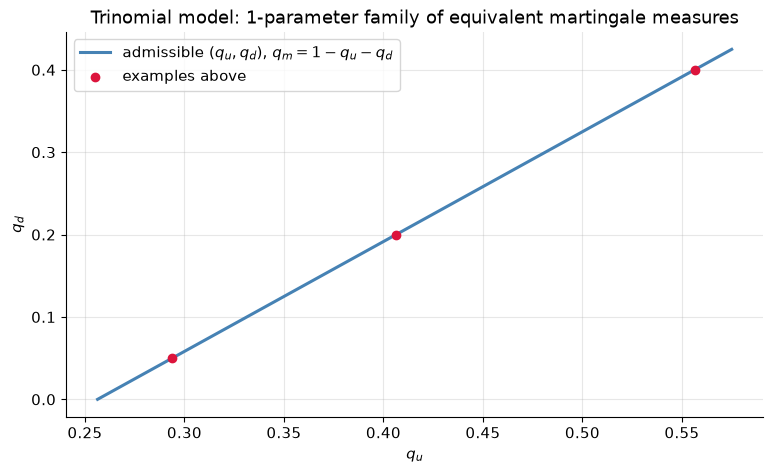

In [3]:
# Demo 2: family of EMMs on a one-step trinomial tree, parametrized by t = q_d
u2, m2, d2, r2, T2, S0_2 = 1.2, 1.0, 0.85, 0.05, 1.0, 100.0
R2 = np.exp(r2 * T2)


def q_from_t(t):
    # Solve {q_u+q_m+q_d=1, u*q_u+m*q_m+d*q_d=R2} for q_u, q_m given q_d = t.
    A = np.array([[1.0, 1.0], [u2, m2]])
    b = np.array([1.0 - t, R2 - d2 * t])
    q_u, q_m = np.linalg.solve(A, b)
    return np.array([q_u, q_m, t])


# admissible range: q_u > 0 and q_m > 0 (q_d = t > 0 by construction)
t_grid_fine = np.linspace(1e-6, 1 - 1e-6, 4000)
admissible_mask = np.array([np.all(q_from_t(t) > 0) for t in t_grid_fine])
t_admissible = t_grid_fine[admissible_mask]
t_lo, t_hi = t_admissible.min(), t_admissible.max()
print(f"admissible t = q_d range: ({t_lo:.6f}, {t_hi:.6f})")

t_samples = np.linspace(t_lo, t_hi, 200)
Q_family = np.array([q_from_t(t) for t in t_samples])  # shape (200, 3): columns q_u, q_m, q_d

# a couple of concrete members of the family, for the printed sanity check
Q_examples = np.array([q_from_t(t) for t in [0.05, 0.20, 0.40]])
for t_ex, q_ex in zip([0.05, 0.20, 0.40], Q_examples):
    print(f"t={t_ex:.2f}: Q=(q_u={q_ex[0]:.6f}, q_m={q_ex[1]:.6f}, q_d={q_ex[2]:.6f}), sum={q_ex.sum():.10f}")

fig, ax = plt.subplots()
ax.plot(Q_family[:, 0], Q_family[:, 2], color="steelblue", linewidth=2.2, label=r"admissible $(q_u, q_d)$, $q_m=1-q_u-q_d$")
ax.scatter(Q_examples[:, 0], Q_examples[:, 2], color="crimson", zorder=5, label="examples above")
ax.set_xlabel(r"$q_u$")
ax.set_ylabel(r"$q_d$")
ax.set_title("Trinomial model: 1-parameter family of equivalent martingale measures")
ax.legend()
plt.show()

El conjunto admisible es efectivamente un segmento de recta (proyectado en el plano $(q_u,q_d)$, con $q_m = 1-q_u-q_d$): cada punto es una $\mathbb{Q}$ igualmente válida — equivalente a $\mathbb{P}$ y que hace de $\tilde S$ una martingala — pero cada una asigna un precio distinto a un derivado no replicable, como el intervalo $[\text{precio}_{\inf},\text{precio}_{\sup}]$ que ya vimos en 2.1. Ningún punto del segmento es "más correcto" que otro sin información adicional (una opción cuyo precio de mercado ancle la medida, exactamente lo que hace la Demo 3).

## 6. Demo 3 — Detección de arbitraje vía programación lineal

Añadimos un tercer activo al mercado trinomial de la Demo 2: una **opción call** con strike $K=100$, payoff $(20, 0, 0)$ en los estados $(u,m,d)$. Con 3 activos (bono, acción, call) para 3 estados, la matriz de payoffs
$$
D = \begin{pmatrix} 1 & 120 & 20 \\ 1 & 100 & 0 \\ 1 & 85 & 0 \end{pmatrix} \quad (\text{filas: estados } u,m,d;\ \text{columnas: bono, acción, call})
$$
es invertible ($\det D = -300 \neq 0$): el mercado se **completa**, y por el 2do FTAP la medida $\mathbb{Q}$ queda fija de forma única (elegimos $t=q_d=0.2$ de la familia de la Demo 2, lo cual determina el precio justo de la call vía $\text{disc}\cdot\mathbb{E}^{\mathbb{Q}}[\text{payoff}]$).

### 6.1 El LP de detección de arbitraje

Dado un vector de precios $p \in \mathbb{R}^3$ (uno por activo) y la matriz de payoffs $D$ (estados $\times$ activos), buscamos una estrategia $\theta \in \mathbb{R}^3$ (posiciones, con venta en corto permitida) resolviendo
$$
\min_{\theta} \ p^{\top}\theta \quad \text{s.a.} \quad D\theta \geq 0 \ \text{(cada estado, payoff no negativo)}, \quad \mathbf{1}^{\top}D\theta = 1 \ \text{(payoff total normalizado a 1)}.
$$
La normalización $\mathbf{1}^\top D\theta=1$ excluye la solución trivial $\theta=0$ y fija la escala (el problema es homogéneo de grado 1 en $\theta$, así que sin normalizar el óptimo sería $-\infty$ o $0$ trivialmente). Si el valor óptimo es **negativo**, $\theta^*$ es una oportunidad de arbitraje explícita: cuesta menos que cero hoy ($p^\top\theta^* < 0$, se recibe dinero) y el payoff es no negativo en todo estado y estrictamente positivo en total. Si el óptimo es $\geq 0$, no existe tal estrategia normalizada — y por homogeneidad, tampoco existe ninguna oportunidad de arbitraje sin normalizar. Este es el mismo par (subespacio, cono positivo) del esbozo de demostración del 1er FTAP (Sección 2.1): aquí el subespacio $\mathcal{G}$ es reemplazado por el cono $\{D\theta : \theta\in\mathbb{R}^3\}$ generado por activos negociables reales (no necesariamente de costo cero), y la LP es literalmente el problema de separación resuelto numéricamente.

In [4]:
# Demo 3: arbitrage detection via linprog in a 3-asset market (bond, stock, call)
D = np.array([
    [1.0, 120.0, 20.0],   # state u
    [1.0, 100.0, 0.0],    # state m
    [1.0, 85.0, 0.0],     # state d
])  # rows: states (u, m, d); columns: assets (bond, stock, call)

disc = np.exp(-r2 * T2)
t_star = 0.20
q_star = q_from_t(t_star)  # unique EMM once the call completes the market
call_payoff = np.array([20.0, 0.0, 0.0])
fair_call_price = disc * float(q_star @ call_payoff)
print(f"Q* (t={t_star}) = {q_star}")
print(f"fair call price under Q* = {fair_call_price:.6f}")

prices_consistent = np.array([disc, S0_2, fair_call_price])
prices_arbitrage = prices_consistent.copy()
prices_arbitrage[2] = 4.0  # call mispriced well below its replication cost -> arbitrage


def detect_arbitrage(prices, D):
    # LP: min p'theta s.t. D theta >= 0, 1'D theta = 1. Negative optimum => arbitrage.
    n_assets = D.shape[1]
    n_states = D.shape[0]
    A_ub = -D                                    # -D theta <= 0  <=>  D theta >= 0
    b_ub = np.zeros(n_states)
    A_eq = (np.ones(n_states) @ D).reshape(1, -1)  # 1' D theta = 1
    b_eq = np.array([1.0])
    return linprog(c=prices, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                    bounds=[(None, None)] * n_assets, method="highs")


res_consistent = detect_arbitrage(prices_consistent, D)
res_arbitrage = detect_arbitrage(prices_arbitrage, D)

print(f"\nConsistent market prices: {prices_consistent}")
print(f"LP optimal value (consistent market): {res_consistent.fun:.6f}  (status={res_consistent.status})")

print(f"\nMispriced market prices:  {prices_arbitrage}")
print(f"LP optimal value (mispriced market):  {res_arbitrage.fun:.6f}  (status={res_arbitrage.status})")

theta_star = res_arbitrage.x
payoff_star = D @ theta_star
cost_star = prices_arbitrage @ theta_star
print(f"\nExplicit arbitrage strategy theta* = (bond={theta_star[0]:.6f}, stock={theta_star[1]:.6f}, call={theta_star[2]:.6f})")
print(f"cost today p'theta* = {cost_star:.6f} (< 0: money received)")
print(f"payoff D theta* = {payoff_star} (>= 0 in every state)")

Q* (t=0.2) = [0.40635548 0.39364452 0.2       ]
fair call price under Q* = 7.730746

Consistent market prices: [  0.95122942 100.           7.73074582]
LP optimal value (consistent market): 0.190246  (status=0)

Mispriced market prices:  [  0.95122942 100.           4.        ]
LP optimal value (mispriced market):  -0.058471  (status=0)

Explicit arbitrage strategy theta* = (bond=6.666667, stock=-0.066667, call=0.066667)
cost today p'theta* = -0.058471 (< 0: money received)
payoff D theta* = [5.55111512e-17 0.00000000e+00 1.00000000e+00] (>= 0 in every state)


En el mercado consistente el óptimo del LP es estrictamente positivo: no existe una estrategia normalizada de costo no positivo, consistente con que los 3 precios fueron construidos a partir de la misma $\mathbb{Q}^*$. En el mercado con la call subvaluada, el óptimo es negativo y `linprog` devuelve $\theta^*$ explícito: la estrategia paga (casi) exactamente 1 en el estado $d$ y 0 en los demás — es la seguridad de Arrow-Debreu del estado $d$, sintetizada a partir de bono+acción+call — y cuesta *menos que cero* hoy. Esto es un arbitraje de tipo 1 (costo $\leq 0$, payoff $\geq 0$, no ambos cero) explícito y verificable componente por componente.

## 7. Validación

Tres chequeos, alineados con las tres demos:

1. La medida binomial única (resuelta por sistema lineal nodo a nodo) coincide con la fórmula cerrada de CRR a `atol=1e-12`.
2. La familia de medidas del trinomial: cada miembro muestreado es una probabilidad válida (suma 1, todas positivas) y satisface exactamente la condición de martingala.
3. El LP de arbitraje: detecta el arbitraje sembrado (óptimo claramente negativo) y no detecta ninguno en el mercado consistente (óptimo claramente no negativo).

In [5]:
# Validation 1: unique binomial EMM matches the closed-form CRR formula (atol 1e-12)
np.testing.assert_allclose(q_path, q_crr, atol=1e-12)
np.testing.assert_allclose(q_path.sum(), 1.0, atol=1e-12)
print(f"Validation 1 passed: node-by-node linear solve matches CRR formula at atol=1e-12 (max |diff| = {np.max(np.abs(q_path - q_crr)):.2e}).")

# Validation 2: every sampled member of the trinomial family is a valid, martingale-consistent probability
sums = Q_family.sum(axis=1)
np.testing.assert_allclose(sums, 1.0, atol=1e-10)
assert np.all(Q_family > 0), "all q_u, q_m, q_d must be strictly positive (equivalence to P)"
martingale_check = Q_family @ np.array([u2, m2, d2])
np.testing.assert_allclose(martingale_check, R2, atol=1e-10)
print(f"Validation 2 passed: {len(Q_family)} sampled measures all sum to 1, all strictly positive, "
      f"and satisfy E^Q[S_T/S_0] = e^(rT) = {R2:.6f} at atol=1e-10.")

# Validation 3: the LP flags the seeded arbitrage and clears the consistent market
lp_tol = 1e-6
assert res_arbitrage.fun < -lp_tol, "LP should detect a clearly negative optimum in the mispriced market"
assert res_consistent.fun > -lp_tol, "LP should NOT detect arbitrage in the consistent market"
np.testing.assert_allclose(np.minimum(payoff_star, 0.0), 0.0, atol=1e-8)  # payoff >= 0 in every state
assert cost_star < -lp_tol, "explicit arbitrage strategy must have strictly negative cost today"
print(f"Validation 3 passed: LP optimum = {res_arbitrage.fun:.6f} (< -{lp_tol}) in the mispriced market, "
      f"{res_consistent.fun:.6f} (>= -{lp_tol}) in the consistent market; "
      f"extracted theta* has cost {cost_star:.6f} < 0 and payoff >= 0 in all states.")

Validation 1 passed: node-by-node linear solve matches CRR formula at atol=1e-12 (max |diff| = 5.55e-16).
Validation 2 passed: 200 sampled measures all sum to 1, all strictly positive, and satisfy E^Q[S_T/S_0] = e^(rT) = 1.051271 at atol=1e-10.
Validation 3 passed: LP optimum = -0.058471 (< -1e-06) in the mispriced market, 0.190246 (>= -1e-06) in the consistent market; extracted theta* has cost -0.058471 < 0 and payoff >= 0 in all states.


## Referencias

- Harrison, J.M. y Pliska, S.R. (1981). *Martingales and Stochastic Integrals in the Theory of Continuous Trading*. Stochastic Processes and their Applications, 11(3), 215-260.
- Delbaen, F. y Schachermayer, W. (1994). *A General Version of the Fundamental Theorem of Asset Pricing*. Mathematische Annalen, 300, 463-520. (panorama del caso general, con arbitraje asintótico "no free lunch with vanishing risk")
- Shreve, S. (2004). *Stochastic Calculus for Finance I: The Binomial Asset Pricing Model*. Springer. Capítulo 2.